# Guía completa de uso y documentación de `pyMagicStat`

Esta es la guía oficial e interactiva de **pyMagicStat**. Presenta distribución,
inferencia, remuestreo, optimización experimental, regresión y visualización.

## Contenido

1. Configuración del entorno.
2. Distribuciones (`pyMagicStat.distributions`).
3. Inferencia y motor de validación:
   - evaluación de datos y supuestos;
   - robustez muestral calibrada;
   - selección del método;
   - ejecución estadística;
   - intervalos, pruebas t, bootstrap y ANOVA one-way.
4. Inferencia no paramétrica (`pyMagicStat.inference.non_parametric`).
5. Optimización de experimentos (`pyMagicStat.optimization.orchestrator`).
6. Regresión lineal (`pyMagicStat.models.regression`).
7. Visualización y utilidades.

In [ ]:
import copy
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Buscar la raíz del proyecto para importar pyMagicStat desde cualquier carpeta.
root_path = os.path.abspath('.')
while root_path:
    package_init = os.path.join(root_path, 'pyMagicStat', '__init__.py')
    if os.path.exists(package_init):
        break
    parent = os.path.dirname(root_path)
    if parent == root_path:
        break
    root_path = parent

if os.path.exists(os.path.join(root_path, 'pyMagicStat', '__init__.py')):
    if root_path not in sys.path:
        sys.path.insert(0, root_path)
    print(f"Proyecto detectado en: {root_path}")
else:
    print("ADVERTENCIA: no se detectó la raíz de pyMagicStat.")

import pyMagicStat
from pyMagicStat.assumptions import (
    InferenceDesign,
    InferenceValidator,
    OneWayRobustness,
    RobustnessLevel,
    SamplingRobustness,
)
from pyMagicStat.distributions.distributions import (
    BinomialDistribution,
    Distribution,
    LognormalDistribution,
    NormalDistribution,
    PoissonDistribution,
)
from pyMagicStat.inference import (
    BootstrapCI,
    BootstrapMeanDifferenceCI,
    MethodSelector,
    OneWayANOVA,
    WelchANOVA,
)
from pyMagicStat.inference.non_parametric import kruskalWallisTest
from pyMagicStat.inference.parametric import (
    OneSampleTTest,
    PairedTTest,
    ParametricMethod,
    PopulationMeanCI,
    PopulationProportionCI,
    PopulationVarianceCI,
    TwoSampleTTest,
    VarianceHomogeneityTest,
)
from pyMagicStat.models.regression import RegressionModel
from pyMagicStat.optimization.orchestrator import (
    OptimizedExperimentationIteration,
    StatisticalEvaluator,
)
from pyMagicStat.utils.utils import output_format
from pyMagicStat.viz.plots import plot_distribution_summary

print("Librerías importadas correctamente")
print("Paquete cargado desde:", os.path.dirname(pyMagicStat.__file__))

## 1. Módulo de Distribuciones (`pyMagicStat.distributions`)

El módulo `distributions` permite encapsular conjuntos de datos en un objeto `Distribution` para calcular automáticamente estadísticas descriptivas fundamentales. Además, provee clases validadoras especializadas para comprobar si los datos se ajustan a distribuciones continuas (Normal, Lognormal) o discretas (Binomial, Poisson).


In [2]:
# Crear datos de ejemplo
np.random.seed(42)
datos_normales = np.random.normal(loc=10.0, scale=2.0, size=100)

# Instanciar la clase Distribution
dist_obj = Distribution(datos_normales)
print("Representación del objeto Distribution:")
print(dist_obj)

# Acceder a estadísticas descriptivas individuales calculadas automáticamente
print("\nEstadísticos individuales:")
print(f"Media: {dist_obj.mean:.4f}")
print(f"Mediana: {dist_obj.median:.4f}")
print(f"Desviación Estándar: {dist_obj.std:.4f}")
print(f"Varianza: {dist_obj.var:.4f}")
print(f"Sesgo (Skewness): {dist_obj.skewness:.4f}")
print(f"Curtosis: {dist_obj.kurtosis:.4f}")
print(f"Rango Intercuartílico (IQR): {dist_obj.iqr:.4f}")


Representación del objeto Distribution:

            Distribution Summary:
            count=100,
            type=None,
            stats:
            mean=9.792306965211813,
            std=1.8072323532892591,
            var=3.266088778775434,
            skewness=-0.17526772024433787,
            kurtosis=-0.15540470774208082,
            median=9.746087416440576,
            mode=ModeResult(mode=np.float64(4.760509791820511), count=np.int64(1)),
            min=4.760509791820511,
            max=13.704556369017876,
            q1=8.798188659007094,
            q3=10.811904104024123,
            iqr=2.013715445017029,
            range=8.944046577197366
        

Estadísticos individuales:
Media: 9.7923
Mediana: 9.7461
Desviación Estándar: 1.8072
Varianza: 3.2661
Sesgo (Skewness): -0.1753
Curtosis: -0.1554
Rango Intercuartílico (IQR): 2.0137


### 1.1 Distribuciones Continuas: Normal y Lognormal

- **`NormalDistribution`**: Realiza los tests estadísticos de Kolmogorov-Smirnov, Shapiro-Wilk y D'Agostino-Pearson. Además, realiza un análisis de regresión lineal sobre los cuantiles empíricos vs. teóricos (Q-Q plot) y asigna un peso a cada test según el tamaño de la muestra.
- **`LognormalDistribution`**: Transforma los datos aplicando el logaritmo natural (requiere datos estrictamente positivos) y ejecuta la validación de normalidad sobre los datos transformados.


In [3]:
# 1. Validación de Distribución Normal
validador_normal = NormalDistribution(datos_normales)
resultados_normal = validador_normal.fit_test()

print("Resultados de la validación Normal:")
for test, res in resultados_normal.items():
    print(f"- {test}: {res}")

# Verificar si se actualizó el tipo en el objeto Distribution
print(f"\n¿Se considera Normal?: {validador_normal.distribution.type.get('Normal')}")

# Obtener los pesos asignados a cada prueba según el tamaño de la muestra (N=100)
pesos = validador_normal.assign_weights()
print(f"Pesos de los tests para N={len(datos_normales)}: {pesos}")

# 2. Validación de Distribución Lognormal
datos_lognormales = np.random.lognormal(mean=1.5, sigma=0.5, size=100)
validador_lognormal = LognormalDistribution(datos_lognormales)
resultados_lognormal = validador_lognormal.fit_test()

print("\nResultados de la validación Lognormal (sobre log-datos):")
print(f"¿Se considera Lognormal?: {validador_lognormal.distribution.type.get('Lognormal')}")


Resultados de la validación Normal:
- KS: {'statistic': np.float64(0.05177647360597687), 'p_value': np.float64(0.9386471491696728)}
- Shapiro: {'statistic': np.float64(0.9898833815158512), 'p_value': np.float64(0.6551676754214462)}
- D'Agostino: {'statistic': np.float64(0.5750300947846619), 'p_value': np.float64(0.7501252792566838)}
- Anderson: {'statistic': np.float64(0.25343395875113117), 'critical_values': [0.555, 0.632, 0.759, 0.885, 1.053], 'significance_levels': [15.0, 10.0, 5.0, 2.5, 1.0]}
- QQ: {'slope': np.float64(1.8363164093926483), 'intercept': np.float64(9.792306965211814), 'p_value_slope': np.float64(0.0), 'p_value_intercept': np.float64(0.0), 'r_squared': np.float64(0.9914997176870064)}

¿Se considera Normal?: True
Pesos de los tests para N=100: {'KS': 0.2, 'Shapiro': 0.2, "D'Agostino": 0.2, 'Anderson': 0.3, 'QQ': 0.1}

Resultados de la validación Lognormal (sobre log-datos):
¿Se considera Lognormal?: True


### 1.2 Distribuciones Discretas: Binomial y Poisson

Las distribuciones discretas heredan de `DiscreteDistributionValidator` y realizan:
1. Una prueba de bondad de ajuste basada en Chi-cuadrado ($\chi^2$).
2. Una validación de si la distribución se aproxima a una Normal bajo ciertas condiciones (para Binomial: $n \cdot p \cdot (1-p) \ge 9$; para Poisson: $\lambda \ge 9$).

- **`BinomialDistribution`**: Si no se proveen $n$ y $p$, la clase los estima por el método de momentos.
- **`PoissonDistribution`**: Estima el parámetro $\lambda$ a partir de la media muestral.


In [4]:
# 1. Validación de Distribución Binomial (por ejemplo, número de éxitos en 20 intentos con p=0.4)
n_verdadero, p_verdadero = 20, 0.4
datos_binomiales = np.random.binomial(n=n_verdadero, p=p_verdadero, size=150)

validador_binom = BinomialDistribution(datos_binomiales)
# Estimar parámetros por momentos
params_estimados = validador_binom.estimate_parameters_moments()
print(f"Parámetros estimados por momentos: n_est = {params_estimados.get('n'):.2f}, p_est = {params_estimados.get('p'):.4f}")

# Ejecutar test de bondad de ajuste
try:
    resultados_binom = validador_binom.fit_test(n=n_verdadero, p=p_verdadero)
    print("\nResultados Binomial:")
    print(f"- Bondad de ajuste (Chi-square): {resultados_binom['goodness_of_fit']}")
    print(f"- ¿Se cumple la aproximación normal?: {resultados_binom['approx_normal']}")
except ValueError as e:
    print(f"\n[Nota de la Librería] Binomial fit_test: {e}")
    print("Resultados de bondad de ajuste calculados:", validador_binom.distribution.type.get('goodness_of_fit'))

# 2. Validación de Distribución Poisson (por ejemplo, con lambda=12)
lambda_verdadero = 12.0
datos_poisson = np.random.poisson(lam=lambda_verdadero, size=150)

validador_poisson = PoissonDistribution(datos_poisson)
try:
    resultados_poisson = validador_poisson.fit_test()
    print("\nResultados Poisson:")
    print(f"- Bondad de ajuste: {resultados_poisson['goodness_of_fit']}")
    print(f"- ¿Se cumple la aproximación normal? (lambda >= 9): {resultados_poisson['approx_normal']}")
except ValueError as e:
    print(f"\n[Nota de la Librería] Poisson fit_test: {e}")
    print("Resultados de bondad de ajuste calculados:", validador_poisson.distribution.type.get('goodness_of_fit'))


Parámetros estimados por momentos: n_est = 20.26, p_est = 0.3923

Resultados Binomial:
- Bondad de ajuste (Chi-square): {'chi2': np.float64(10.409823686205371), 'p_value': np.float64(0.23743116091955777), 'n': 20, 'p': 0.4}
- ¿Se cumple la aproximación normal?: False

Resultados Poisson:
- Bondad de ajuste: {'chi2': np.float64(9.570183044793502), 'p_value': np.float64(0.4789758832672396), 'lambda': np.float64(11.2)}
- ¿Se cumple la aproximación normal? (lambda >= 9): True


## 2. Inferencia: arquitectura y contratos actuales

El motor separa cuatro responsabilidades. Esta separación evita que un
diagnóstico cambie los datos o ejecute inadvertidamente otro procedimiento:

1. **Evaluación de datos y supuestos.** `InferenceValidator` normaliza muestras y
   genera un `AssumptionReport` con calidad, forma, outliers, varianzas e
   independencia declarada por el diseño.
2. **Evaluación de robustez.** `SamplingRobustness` interpreta el reporte para
   inferencia basada en medias.
3. **Decisión.** `MethodSelector` produce un `InferenceDecision`; no transforma
   observaciones ni calcula el test.
4. **Ejecución.** Clases como `OneSampleTTest`, `PairedTTest`,
   `TwoSampleTTest` y `PopulationMeanCI` calculan la inferencia solicitada.

El validator no transforma datos y nunca ejecuta bootstrap automáticamente.
`strict=True` impide ejecutar una prueba paramétrica cuando la decisión es
insuficiente; `strict=False` permite calcularla con sus advertencias y
diagnósticos, pero no convierte la decisión en aprobación.

### TLC/CLT y robustez muestral

El TLC describe la distribución muestral de un estimador bajo condiciones
apropiadas; no vuelve normales los datos observados. Por ello `n >= 30` no es una
garantía, y bootstrap no es una operación llamada «aplicar TLC».

La política vigente es `SamplingRobustness.POLICY_VERSION =
"mean-v2.1-2026-08"`. Combina tamaño muestral, skewness, kurtosis excedente,
observaciones extremas, calidad de datos y contexto del diseño. Sus niveles son:

- `ACCEPTABLE`: condiciones compatibles con inferencia t directa.
- `CAUTION`: aproximación utilizable dentro de rutas calibradas, con cautela.
- `INSUFFICIENT`: los límites calibrados no respaldan inferencia paramétrica de
  medias.

Estos niveles son decisiones de una política reproducible, no teoremas ni
fronteras universales. Consulte `Docs/sampling-robustness-calibration.md` para
la matriz de 152 000 réplicas que sustenta la versión actual.

### 2.1 Validar, decidir y ejecutar

El reporte conserva la evidencia; la decisión explica cómo se interpretó. Para
una muestra, la forma relevante es la de las observaciones. En un diseño
pareado son las diferencias. En dos grupos independientes se diagnostican los
residuos centrados dentro de cada grupo, sin confundir una diferencia real de
medias con falta de normalidad.

`PopulationMeanCI` usa cuantiles Student-t cuando sigma poblacional es
desconocido. La inferencia no sustituye ese error estándar analítico por
bootstrap.

In [ ]:
rng = np.random.default_rng(42)
ventas = rng.normal(loc=100.0, scale=12.0, size=60)

# 1) Diagnóstico y decisión explícitos.
validation = InferenceValidator().validate_one_sample(
    ventas,
    independence="assumed",
)
decision = MethodSelector().select(validation.report)
print("Diseño:", validation.report.design.value)
print("Robustez:", decision.robustness.level.value)
print("Método seleccionado:", decision.selected_method)
print("Política:", SamplingRobustness.POLICY_VERSION)

# 2) Intervalo para la media: sigma desconocido => cuantiles Student-t.
mean_ci = PopulationMeanCI(
    ventas,
    alpha=0.05,
    independence="assumed",
)
mean_result = mean_ci.calculate_interval()
print("CI 95% media:", (mean_result["lb"], mean_result["ub"]))
print("Grados de libertad:", mean_result["df"])

# 3) Prueba t de una muestra con el mismo contrato de validación.
mean_test = OneSampleTTest(
    ventas,
    popmean=100.0,
    independence="assumed",
)
test_result = mean_test.run_test()
print("p-value:", test_result["p_value"])
print("Decisión completa:", test_result["inference_decision"])

In [ ]:
# Proporción: Wilson es el default; Wald debe solicitarse explícitamente.
conversiones = rng.binomial(1, 0.28, size=120)
proportion_result = PopulationProportionCI(conversiones).calculate_interval()
print("CI Wilson:", (proportion_result["lb"], proportion_result["ub"]))

# Varianza poblacional: el pivote chi-square exacto requiere población normal.
# La TLC no elimina este supuesto. En modo estricto debe declararse el modelo.
variance_result = PopulationVarianceCI(
    ventas,
    population_normality="assumed",
    independence="assumed",
    strict=True,
).calculate_interval()
print("CI chi-square de varianza:", (variance_result["lb"], variance_result["ub"]))
print("Política de varianza:", variance_result["variance_inference"])

# Compatibilidad temporal:
# PopulationVarianceCI(ventas) todavía calcula el intervalo histórico, pero
# puede emitir FutureWarning y lo marca como no validado. Para código nuevo,
# declare population_normality y use strict=True.

### 2.2 Pareadas, dos muestras y diagnósticos de varianza

`PairedTTest` evalúa la forma, outliers y calidad de las **diferencias dentro de
cada par**, no las dos columnas por separado como poblaciones independientes.

En `TwoSampleTTest`, Welch es el default (`equal_var=None` o `False`). Student
con varianza común sólo se solicita mediante `equal_var=True`. Levene,
Bartlett y Fligner son diagnósticos: un p-value mayor que alpha no prueba que
las varianzas sean iguales ni actúa como selector binario automático.

El resultado de dos muestras incluye `equal_var_requested` y
`variance_selection_policy`. Durante la transición de API también conserva en
`group1_assumptions` y `group2_assumptions` las claves legacy `is_normal` y
`tlc_applied`. La segunda está deprecada, siempre es `False` y nunca significa
que se haya ejecutado bootstrap o una operación TLC.

In [ ]:
# Pares: el validator trabaja sobre antes - después.
antes = rng.normal(120.0, 10.0, size=40)
despues = antes - rng.normal(4.5, 2.0, size=40)
paired = PairedTTest(
    antes,
    despues,
    alternative="greater",
    independence="assumed",
).run_test()
print("Media de diferencias:", paired["mean_difference"])
print("Assessment de diferencias:", paired["assumptions"]["assessments"]["shape_differences"])

# Dos grupos: Welch es el default, aun si Levene no rechaza.
control = rng.normal(50.0, 4.0, size=50)
tratamiento = rng.normal(53.0, 8.0, size=45)
welch = TwoSampleTTest(
    control,
    tratamiento,
    independence="assumed",
).run_test()
print("Método:", welch["method"])
print("equal_var_requested:", welch["equal_var_requested"])
print("variance_selection_policy:", welch["variance_selection_policy"])
print("Diagnóstico de homogeneidad:", welch["homogeneity_test"])
print("Legacy tlc_applied:", welch["group1_assumptions"]["tlc_applied"])

# Student se solicita explícitamente cuando el modelo de varianza común está
# defendido por el diseño y el conocimiento sustantivo.
student = TwoSampleTTest(
    control,
    tratamiento,
    equal_var=True,
    independence="assumed",
).run_test()
print("Método solicitado explícitamente:", student["method"])

# Levene (mediana), Bartlett y Fligner siguen disponibles como diagnósticos.
for variance_method in ("levene", "bartlett", "fligner"):
    diagnostic = VarianceHomogeneityTest(
        control,
        tratamiento,
        method=variance_method,
    ).run_test()
    print(variance_method, diagnostic["p_value"])

### 2.3 Bootstrap y ANOVA one-way

Bootstrap es una metodología de remuestreo independiente. Puede preservar una
pregunta sobre la media o diferencia de medias; no «normaliza» la muestra y no
se activa automáticamente cuando falla un diagnóstico.

`BootstrapCI` soporta los backends `scipy` y `numba`. SciPy permite intervalos
`percentile`, `basic` y `bca`; Numba soporta actualmente `percentile`.
`random_state` acepta un entero o un `numpy.random.Generator`. Un estado
explícito hace repetibles llamadas equivalentes, incluso sobre la misma
instancia, y no avanza el Generator entregado por el llamador.

Para `stat="variance"`, `ddof=1` es el default documentado y aplica el estimador
de varianza muestral tanto a la muestra observada como a cada réplica.
`ddof=0` solicita explícitamente el segundo momento central empírico/MLE.

#### One-way ANOVA

Para `k >= 3` grupos independientes, `validate_one_way` evalúa calidad por
grupo, residuos centrados/estandarizados, influencia, balance y varianzas sin
pooling de medias. `OneWayRobustness.POLICY_VERSION` es
`"anova-v1-2026-08"`, calibrada separadamente con 27 000 réplicas.

`MethodSelector` usa Welch ANOVA como default calibrado. Classical requiere
`equal_var=True` y evidencia conjunta compatible; Brown-Forsythe/Levene,
Fligner, Bartlett y razones de magnitud son diagnósticos, y `p > .05` no prueba
varianza común. `OneWayANOVA` ejecuta Classical y `WelchANOVA` ejecuta Welch.

La prueba es global: un rechazo indica que al menos una media difiere, no cuáles.
Esta versión no implementa Tukey, Games-Howell ni otros post-hoc. Kruskal-Wallis
responde una pregunta de rangos/distribuciones diferente.

In [ ]:
datos_sesgados = rng.exponential(scale=5.0, size=120)

# SciPy: BCa reproducible.
scipy_boot = BootstrapCI(
    datos_sesgados,
    stat="mean",
    method="scipy",
    interval_method="bca",
    n_resamples=2_000,
    random_state=20260827,
)
scipy_first = scipy_boot.compute()
scipy_second = scipy_boot.compute()
print("SciPy repetible:", scipy_first == scipy_second, scipy_first)

# Numba: percentil reproducible.
numba_boot = BootstrapCI(
    datos_sesgados,
    stat="median",
    method="numba",
    interval_method="percentile",
    n_resamples=2_000,
    random_state=20260827,
)
print("Numba repetible:", numba_boot.compute() == numba_boot.compute())

# El Generator externo se clona; su estado no se consume.
external_rng = np.random.default_rng(99)
state_before = copy.deepcopy(external_rng.bit_generator.state)
BootstrapCI(
    datos_sesgados,
    random_state=external_rng,
    n_resamples=1_000,
).compute()
print("Generator externo intacto:", external_rng.bit_generator.state == state_before)

# Bootstrap de varianza: ddof queda registrado en el resultado.
variance_boot = BootstrapCI(
    datos_sesgados,
    stat="variance",
    ddof=1,
    random_state=7,
).compute()
print("ddof:", variance_boot["ddof"], "CI:", (variance_boot["lb"], variance_boot["ub"]))

# ANOVA: validar, seleccionar y ejecutar permanecen como pasos separados.
anova_groups = (
    rng.normal(100, 8, 35),
    rng.normal(105, 12, 45),
    rng.normal(110, 20, 55),
)
one_way_validation = InferenceValidator().validate_one_way(
    *anova_groups,
    independence="assumed",
)
one_way_decision = MethodSelector().select(one_way_validation.report)
assert one_way_validation.report.design is InferenceDesign.ONE_WAY
print("Política:", OneWayRobustness.POLICY_VERSION)
print("Default:", one_way_decision.selected_method)

if one_way_decision.selected_method == "welch_anova":
    anova_result = WelchANOVA(
        *anova_groups,
        independence="assumed",
    ).run_test()
    print(anova_result["method"], anova_result["p_value"])

# Classical se solicita explícitamente y puede ser denegado si el modelo de
# varianza común no está respaldado.
classical_decision = MethodSelector().select(
    one_way_validation.report,
    equal_var=True,
)
print("Classical explícito:", classical_decision.selected_method)

## 3. Inferencia no paramétrica y estimands

Una alternativa debe interpretarse según la pregunta que responde:

- Bootstrap de la media o de diferencias de medias conserva ese estimand si el
  esquema de remuestreo respeta el diseño.
- Mann-Whitney describe orden probabilístico/rangos bajo sus condiciones; no es
  en general una prueba de igualdad de medias.
- Kruskal-Wallis detecta diferencias de distribuciones de rangos. No es
  simplemente «ANOVA no paramétrico de medias».

La clase histórica `kruskalWallisTest` incluye funcionalidad post-hoc propia;
el motor ANOVA paramétrico actual no incluye ni ejecuta post-hoc.

### Limitación numérica conocida

La tolerancia de degeneración de `DataQualityAssessment` puede perder
invariancia de escala en la región subnormal de float64, aproximadamente desde
`1e-139` y especialmente alrededor de `1e-146` o menos. No es un riesgo
material para el alcance actual de BI y analítica comercial. El alcance, causa,
ejemplos y estrategia futura están registrados en `Docs/technical-debt.md` bajo
«Numerical hardening for subnormal float64 scales».

In [ ]:
# Intervalo bootstrap de la diferencia de medias, preservando grupos independientes.
mean_difference = BootstrapMeanDifferenceCI(
    control,
    tratamiento,
    interval_method="bca",
    n_resamples=2_000,
    random_state=42,
).compute()
print("Bootstrap CI diferencia de medias:", mean_difference)

In [10]:
# Crear tres grupos con distribuciones y medias ligeramente distintas
grupo_A = np.random.normal(loc=10.0, scale=1.5, size=50)
grupo_B = np.random.normal(loc=10.5, scale=1.5, size=50)
grupo_C = np.random.normal(loc=12.0, scale=1.5, size=50)

# Instanciar el test con etiquetas explicativas
kw_test = kruskalWallisTest(grupo_A, grupo_B, grupo_C, labels=["Grupo A", "Grupo B", "Grupo C"])
resultados_kw = kw_test.run_test()

print("Resultados de la Prueba de Kruskal-Wallis:")
print(f"Estadístico H: {resultados_kw['H_statistic']:.4f}")
print(f"Valor p global: {resultados_kw['p_value']:.4e}")
print(f"Grados de libertad: {resultados_kw['df']}")

print("\nAnálisis por grupos (Comparaciones Post-hoc vs Resto de grupos):")
for grp in resultados_kw['Groups']:
    print(f"- {grp['Label']}: SSW={grp['SSW']:.2f}, R² individual={grp['R^2']:.4f}, valor p post-hoc={grp['p_value']:.4e}")

# Demostrar eliminación de un grupo y actualización automática de R^2
print("\nEliminando el 'Grupo A' (índice 0)...")
kw_test.remove_group(0)
print("Grupos restantes:", kw_test.labels)
print("Suma de cuadrados totales recalculada:", kw_test.ss_total)


Resultados de la Prueba de Kruskal-Wallis:
Estadístico H: 46.0228
Valor p global: 1.0146e-10
Grados de libertad: 2

Análisis por grupos (Comparaciones Post-hoc vs Resto de grupos):
- Grupo A: SSW=120.22, R² individual=0.7936, valor p post-hoc=1.4367e-07
- Grupo B: SSW=139.20, R² individual=0.7610, valor p post-hoc=2.8263e-01
- Grupo C: SSW=144.56, R² individual=0.7518, valor p post-hoc=2.3442e-10

Eliminando el 'Grupo A' (índice 0)...
Grupos restantes: ['Grupo B', 'Grupo C']
Suma de cuadrados totales recalculada: 362.3136247300555


## 4. Módulo de Optimización de Experimentos (`pyMagicStat.optimization.orchestrator`)

El módulo `optimization` coordina la selección de subconjuntos óptimos de grupos para maximizar la representatividad y significancia estadística (medido mediante $R^2$).
Se compone de:
- **`StatisticalEvaluator`**: Envuelve una clase de test (como `kruskalWallisTest`) para evaluar un conjunto de grupos.
- **`OptimizedExperimentationIteration`**: Ejecuta iteraciones de búsqueda utilizando tres estrategias:
  - **Greedy (`greedy`)**: Elimina en cada paso el grupo con el peor valor p post-hoc (mayor p-value), hasta que el $R^2$ global alcanza el objetivo (`r2_target`) o quedan menos de 2 grupos.
  - **Exhaustive (`exhaustive`)**: Evalúa todas las combinaciones posibles de grupos para encontrar la combinación que maximice el $R^2$.
  - **Simulated Annealing (`simulated_annealing`)**: Utiliza una heurística estocástica probabilística (basada en temperatura inicial y tasa de enfriamiento) para navegar el espacio de soluciones de agrupaciones.


In [11]:
# Crear un conjunto amplio de 6 grupos (algunos con diferencias notables)
g1 = np.random.normal(10, 1.0, 30)
g2 = np.random.normal(10, 1.1, 30)
g3 = np.random.normal(10.2, 1.0, 30)
g4 = np.random.normal(11.5, 1.2, 30) # Distinto
g5 = np.random.normal(12.0, 1.0, 30) # Muy distinto
g6 = np.random.normal(10, 0.9, 30)

grupos_lista = [g1, g2, g3, g4, g5, g6]
nombres_grupos = ["G1", "G2", "G3", "G4", "G5", "G6"]

# 1. Configurar el Evaluador Estadístico basado en Kruskal-Wallis
evaluador = StatisticalEvaluator(kruskalWallisTest)

# 2. Ejecutar Optimización con la estrategia Greedy
opt_greedy = OptimizedExperimentationIteration(
    evaluator=evaluador,
    groups=grupos_lista,
    labels=nombres_grupos,
    strategy="greedy",
    r2_target=0.45
)
historial_greedy = opt_greedy.run()
print("A) OPTIMIZACIÓN GREEDY:")
print(f"Número de iteraciones realizadas: {len(historial_greedy)}")
print(f"Mejor configuración final: {historial_greedy[-1]['groups']}")
print(f"R² global final: {historial_greedy[-1]['global_R2']:.4f}")

# 3. Ejecutar Optimización con la estrategia Exhaustiva
opt_exh = OptimizedExperimentationIteration(
    evaluator=evaluador,
    groups=grupos_lista,
    labels=nombres_grupos,
    strategy="exhaustive"
)
resultado_exh = opt_exh.run()
print("\nB) OPTIMIZACIÓN EXHAUSTIVA:")
print(f"Mejor combinación de grupos: {resultado_exh['best_groups']}")
print(f"Mejor R² global alcanzado: {resultado_exh['best_r2']:.4f}")

# 4. Ejecutar Optimización con Simulated Annealing
opt_sa = OptimizedExperimentationIteration(
    evaluator=evaluador,
    groups=grupos_lista,
    labels=nombres_grupos,
    strategy="simulated_annealing",
    max_iterations=50,
    initial_temperature=1.5,
    cooling_rate=0.9
)
resultado_sa = opt_sa.run()
print("\nC) OPTIMIZACIÓN POR RECOCIDO SIMULADO (Simulated Annealing):")
print(f"Mejor combinación de grupos: {resultado_sa['best_groups']}")
print(f"Mejor R² global alcanzado: {resultado_sa['best_r2']:.4f}")


A) OPTIMIZACIÓN GREEDY:
Número de iteraciones realizadas: 1
Mejor configuración final: ['G1', 'G2', 'G3', 'G4', 'G5', 'G6']
R² global final: 0.4829

B) OPTIMIZACIÓN EXHAUSTIVA:
Mejor combinación de grupos: ['G5', 'G6']
Mejor R² global alcanzado: 0.6846



C) OPTIMIZACIÓN POR RECOCIDO SIMULADO (Simulated Annealing):
Mejor combinación de grupos: ['G5', 'G6']
Mejor R² global alcanzado: 0.6846


## 5. Módulo de Regresión Lineal (`pyMagicStat.models.regression`)

La clase **`RegressionModel`** permite ajustar modelos de regresión lineal por mínimos cuadrados ordinarios (OLS) a partir de un DataFrame de Pandas. Su diseño está orientado tanto al diagnóstico de relaciones (estadística explicativa) como a la predicción de nuevas observaciones.

Características destacadas:
- Admite fórmulas R/statsmodels (ej. `'precio ~ superficie + C(barrio)'`), permitiendo codificar variables categóricas.
- Detecta y documenta las categorías base de referencia para cada variable en la ecuación resultante.
- Ejecuta pruebas diagnósticas automáticamente sobre los residuos para validar la hipótesis de normalidad de los errores.
- Genera un resumen estadístico completo y renderiza gráficos diagnósticos directamente en el notebook.


In [12]:
# Crear un dataset sintético para el modelo de regresión
np.random.seed(42)
n_muestras = 150
superficie = np.random.uniform(50, 180, n_muestras)
barrio = np.random.choice(['Norte', 'Sur', 'Centro'], size=n_muestras)

# Generar precio dependiente de superficie, barrio y algo de ruido
ruido = np.random.normal(0, 15, n_muestras)
efectos_barrio = {'Norte': 30, 'Centro': 15, 'Sur': 0}
precio = 50 + 2.5 * superficie + np.array([efectos_barrio[b] for b in barrio]) + ruido

df_casas = pd.DataFrame({
    'precio': precio,
    'superficie': superficie,
    'barrio': barrio
})

# Instanciar el modelo de regresión con variables continuas y categóricas
modelo_reg = RegressionModel(data=df_casas, formula="precio ~ superficie + C(barrio)")

# 1. Obtener la ecuación matemática y bases categóricas
ecuacion = modelo_reg.get_equation()
print("Ecuación del Modelo y Categorías de Referencia:")
print(ecuacion)

# 2. Computar las métricas de diagnóstico (R², AIC, BIC, normalidad de residuos)
metricas = modelo_reg.compute_metrics()
print("\nMétricas de ajuste y diagnóstico:")
print(f"- R² del modelo: {metricas['r_squared']:.4f}")
print(f"- R² Ajustado: {metricas['adj_r_squared']:.4f}")
print(f"- AIC: {metricas['aic']:.2f} | BIC: {metricas['bic']:.2f}")
print(f"- ¿Residuos Normales? (P-value Shapiro-Wilk): {metricas['residual_normality'].get('Shapiro', {}).get('p_value', 0):.4f}")


Ecuación del Modelo y Categorías de Referencia:
precio = 63.579 + 17.434*[C(barrio)[T.Norte]] + -16.978*[C(barrio)[T.Sur]] + 2.507*[superficie]
Categoría base para 'barrio': Centro

Métricas de ajuste y diagnóstico:
- R² del modelo: 0.9781
- R² Ajustado: 0.9777
- AIC: 1244.80 | BIC: 1256.84
- ¿Residuos Normales? (P-value Shapiro-Wilk): 0.2548


### 5.1 Gráficos de Residuos y Predicción

El método `.summary(verbose=True)` muestra las estadísticas completas de ajuste y además renderiza automáticamente la visualización cuádruple de residuos de la regresión.
Finalmente, podemos usar el método `.predict()` para calcular valores ajustados sobre nuevas observaciones.


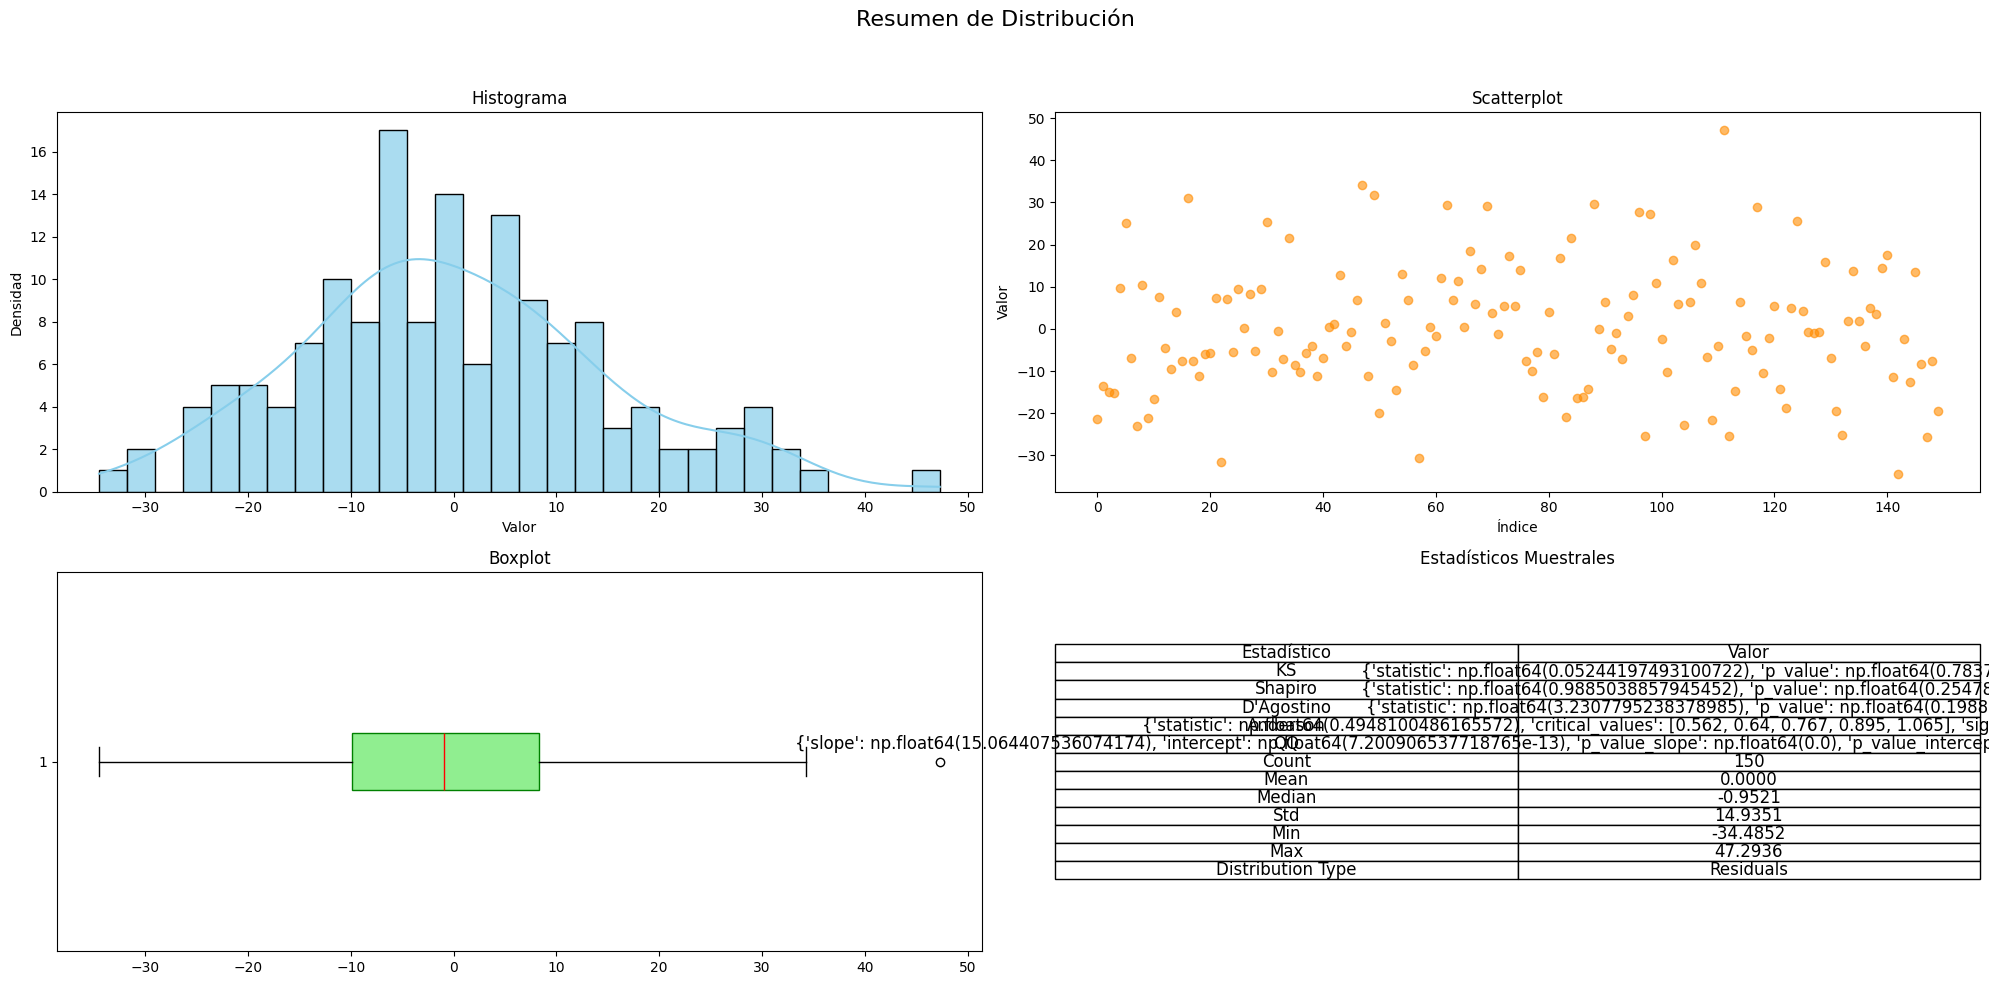


Predicciones para nuevas propiedades:
- Superficie: 80.0m², Barrio: Norte -> Precio Estimado: 281.58 k$
- Superficie: 120.0m², Barrio: Centro -> Precio Estimado: 364.43 k$
- Superficie: 150.0m², Barrio: Sur -> Precio Estimado: 422.66 k$


In [13]:
# 3. Renderizar resumen estadístico y diagnóstico visual de residuos
# Esto mostrará la tabla oficial de coeficientes de statsmodels y llamará al gráfico cuádruple
modelo_reg.summary(verbose=True)

# 4. Realizar predicciones en un nuevo conjunto de datos
nuevos_datos = pd.DataFrame({
    'superficie': [80.0, 120.0, 150.0],
    'barrio': ['Norte', 'Centro', 'Sur']
})
predicciones = modelo_reg.predict(nuevos_datos)
print("\nPredicciones para nuevas propiedades:")
for i, pred in enumerate(predicciones):
    sup = nuevos_datos.loc[i, 'superficie']
    bar = nuevos_datos.loc[i, 'barrio']
    print(f"- Superficie: {sup}m², Barrio: {bar} -> Precio Estimado: {pred:.2f} k$")


## 6. Módulo de Visualización y Utilidades (`pyMagicStat.viz` y `pyMagicStat.utils`)

Para mayor flexibilidad, podemos llamar individualmente a las funciones auxiliares de la biblioteca:
- **`plot_distribution_summary`**: Genera un gráfico cuádruple (Histograma con KDE, Scatterplot de dispersión, Boxplot horizontal y Tabla de métricas) para cualquier arreglo de datos.
- **`output_format`**: Estandariza las respuestas de las funciones del sistema en diccionarios consistentes.


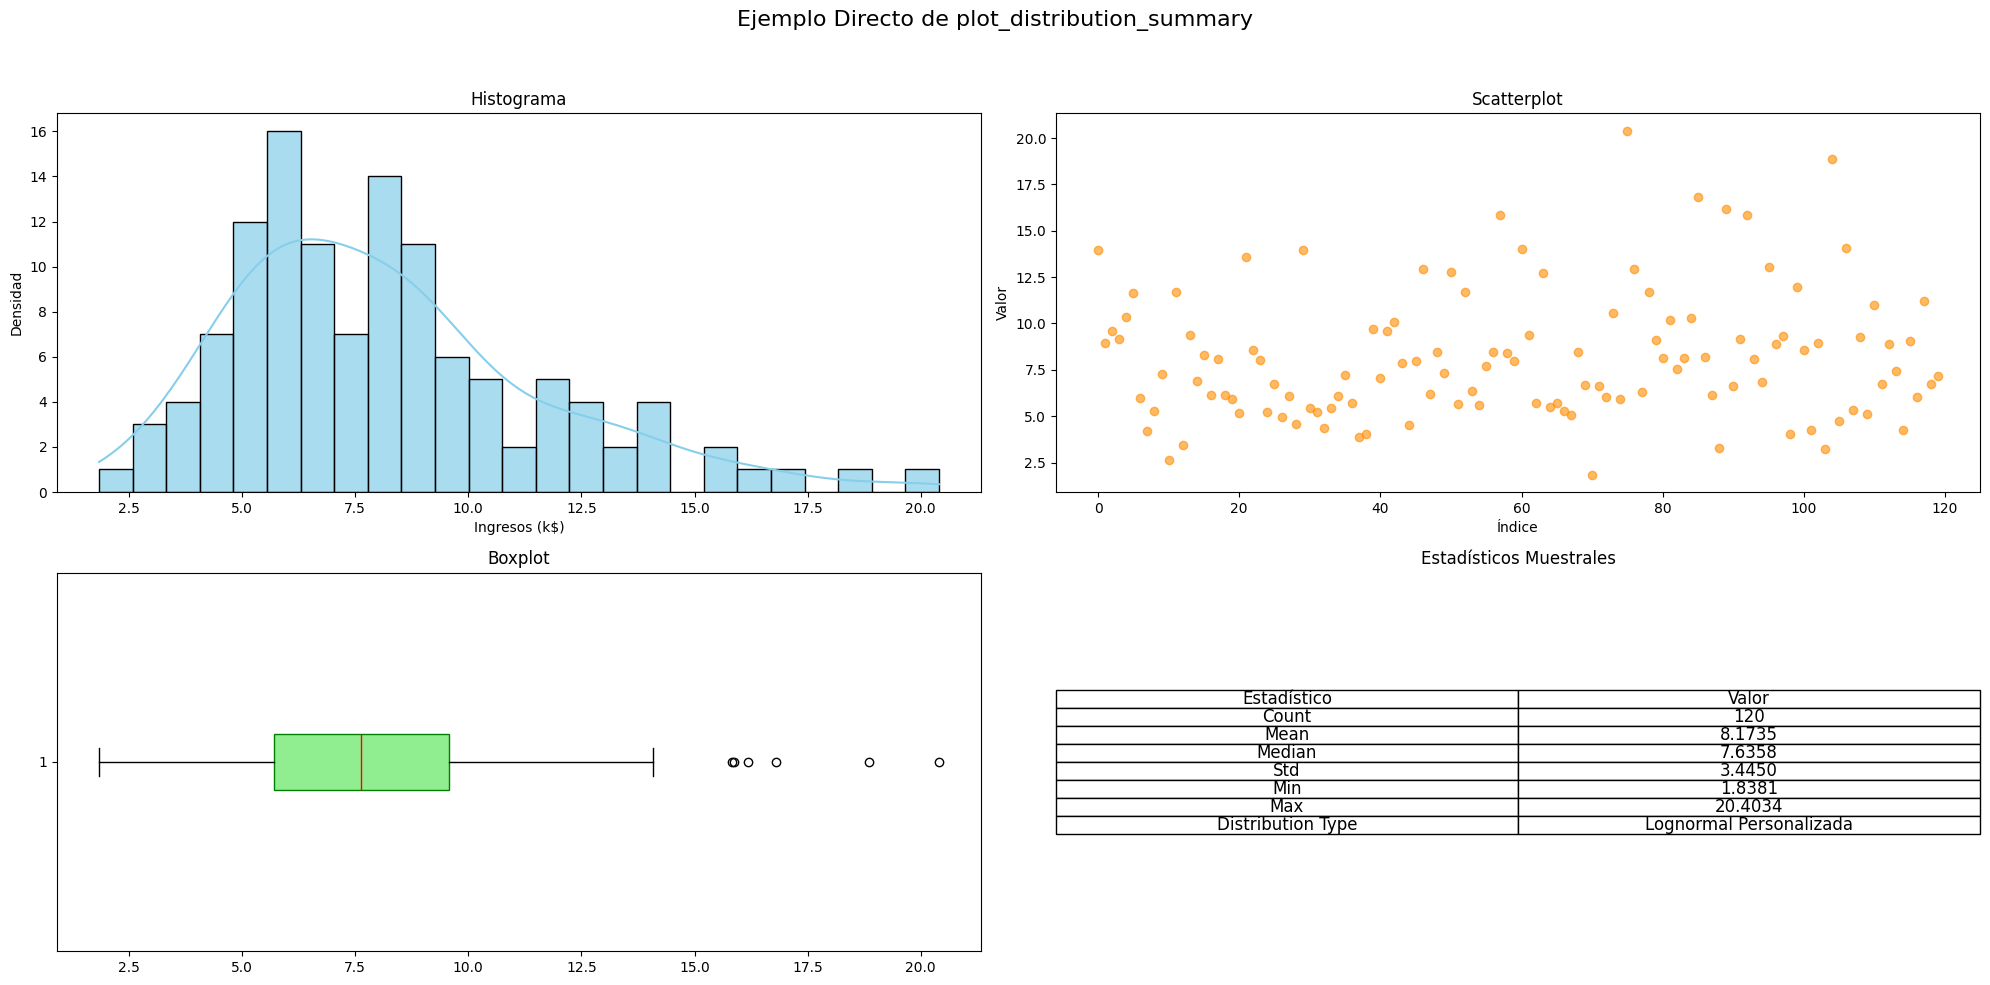


Estructura formateada por output_format:
{'lb': 1.25, 'ub': 3.9, 'p_value': 0.012, 'Result': np.True_, 'txt': 'Proceso completado exitosamente'}


In [14]:
# Utilizar plot_distribution_summary directamente con datos personalizados (distribución Lognormal)
datos_log = np.random.lognormal(mean=2.0, sigma=0.4, size=120)
plot_distribution_summary(
    data=datos_log, 
    distribution_type="Lognormal Personalizada", 
    title="Ejemplo Directo de plot_distribution_summary",
    x_label="Ingresos (k$)",
    bins=25
)

# Utilizar la función output_format para estandarizar salidas
resultado_limpio = output_format(lb=1.25, ub=3.90, p_value=0.012, bool_result=True, txt="Proceso completado exitosamente")
print("\nEstructura formateada por output_format:")
print(resultado_limpio)
